<a href="https://colab.research.google.com/github/beantkapoor786/python-mastery/blob/main/AI_chatbot_data_school_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# generate the conda env for ai chatbot
! pip install -q condacolab

In [ ]:
import condacolab

In [ ]:
condacolab.install()

✨🍰✨ Everything looks OK!


In [ ]:
! conda --version

conda 24.11.2


In [ ]:
!conda create -n chatbot -c conda-forge langchain langchain-openai langgraph python-dotenv jupyter

Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ | / done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 25.3.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/chatbot

  added / updated specs:
    - jupyter
    - langchain
    - langchain-openai
    - langgraph
    - python-dotenv


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    aiohappyeyeballs-2.6.1     |     pyhd8ed1ab_0          19 KB  conda-forge
    aiohttp-3.11.18            |  py312h178313f_0         898 KB  conda-forge
    aiosignal-1.3.2            |     pyhd8ed1ab_0          13 KB  conda-forge
    annotated-types-0.7.0      |     pyhd8ed1ab_1          18 KB  conda-forge
    anyio-4.9.0                |     pyh29332c3_0         123 KB  conda-forge
   

In [ ]:
!conda init bash

no change     /usr/local/condabin/conda
no change     /usr/local/bin/conda
no change     /usr/local/bin/conda-env
no change     /usr/local/bin/activate
no change     /usr/local/bin/deactivate
no change     /usr/local/etc/profile.d/conda.sh
no change     /usr/local/etc/fish/conf.d/conda.fish
no change     /usr/local/shell/condabin/Conda.psm1
no change     /usr/local/shell/condabin/conda-hook.ps1
no change     /usr/local/lib/python3.11/site-packages/xontrib/conda.xsh
no change     /usr/local/etc/profile.d/conda.csh
no change     /root/.bashrc
No action taken.


In [ ]:
!conda activate chatbot


CondaError: Run 'conda init' before 'conda activate'



In [ ]:
! pip install -qU langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.2/661.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.0/763.0 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 792.7/792.7 kB 44.7 MB/s eta 0:00:00


In [ ]:
import getpass
import os

if not os.environ.get("OPENAI_API_KEY"):
  os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

Enter API key for OpenAI: ··········


In [ ]:
# this is the chat model, there are other models available but this is the standard one
from langchain_openai import ChatOpenAI

# imports used to build chatbot
from langgraph.graph import StateGraph, MessagesState, START

# NOTE - langgraph was installed using pip - ! pip install langgraph

# in memory checkpointer
from langgraph.checkpoint.memory import MemorySaver

# create a model object to define which model we are using
model = ChatOpenAI(model="gpt-4o-mini")

# this function accepts current state of the graph which is the list of messages
def call_model(state: MessagesState):
  updated_messages = model.invoke(state["messages"])
  return {"messages": updated_messages}

workflow = StateGraph(MessagesState)
workflow.add_node("model_node", call_model)
workflow.add_edge(START, "model_node")

memory = MemorySaver()
app = workflow.compile(memory)

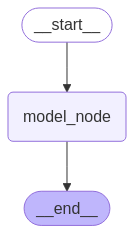

In [ ]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [ ]:
chat1 = {"configurable": {"thread_id": 1}}
app.invoke({"messages": "My name is Beant."}, chat1)

{'messages': [HumanMessage(content='My name is Beant.', additional_kwargs={}, response_metadata={}, id='23e2d76a-c26c-4e39-b5fb-1d3a0399ee0e'),
  AIMessage(content='Nice to meet you, Beant! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 13, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BRkUnU5w0WgNVv6dx3UDXQXGuNY6N', 'finish_reason': 'stop', 'logprobs': None}, id='run-bb9ac551-68ea-47cc-a5bf-3a6e378dc319-0', usage_metadata={'input_tokens': 13, 'output_tokens': 16, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [ ]:
app.invoke({"messages": "What is my name?"}, chat1)

{'messages': [HumanMessage(content='My name is Beant.', additional_kwargs={}, response_metadata={}, id='23e2d76a-c26c-4e39-b5fb-1d3a0399ee0e'),
  AIMessage(content='Nice to meet you, Beant! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 13, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BRkUnU5w0WgNVv6dx3UDXQXGuNY6N', 'finish_reason': 'stop', 'logprobs': None}, id='run-bb9ac551-68ea-47cc-a5bf-3a6e378dc319-0', usage_metadata={'input_tokens': 13, 'output_tokens': 16, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  HumanMessage(content='What 

In [ ]:
output = app.invoke(None, chat1)

In [ ]:
[message.pretty_print() for message in output["messages"]]

================================ Human Message =================================

My name is Beant.
================================== Ai Message ==================================

Nice to meet you, Beant! How can I assist you today?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Beant. How can I help you further?


[None, None, None, None]

In [ ]:
app.invoke({"messages": "How is the weather today in Knoxville TN"}, chat1)

{'messages': [HumanMessage(content='My name is Beant.', additional_kwargs={}, response_metadata={}, id='23e2d76a-c26c-4e39-b5fb-1d3a0399ee0e'),
  AIMessage(content='Nice to meet you, Beant! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 13, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BRkUnU5w0WgNVv6dx3UDXQXGuNY6N', 'finish_reason': 'stop', 'logprobs': None}, id='run-bb9ac551-68ea-47cc-a5bf-3a6e378dc319-0', usage_metadata={'input_tokens': 13, 'output_tokens': 16, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  HumanMessage(content='What 

In [ ]:
[message.pretty_print() for message in output["messages"]]

================================ Human Message =================================

My name is Beant.
================================== Ai Message ==================================

Nice to meet you, Beant! How can I assist you today?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Beant. How can I help you further?


[None, None, None, None]

In [ ]:
chat2 = {"configurable": {"thread_id": 2}}

In [ ]:
app.invoke({"messages": "What is my name?"}, chat2)["messages"][-1].content

"I still don't have any information about your name. If you'd like to share your name or have any other questions, feel free to let me know!"

In [ ]:
# now we can create a function which makes it like ChatGPT
def chatbot(chat_id: int):
  config = {'configurable': {'thread_id': chat_id}}
  while True:
    user_input = input("User:")

    if user_input in ["exit", "quit"]:
      print("AI: See you later, Alligator!")
      break

    else:
      output = app.invoke({"messages": user_input}, config)
      print("AI:", output["messages"][-1].content, end="\n\n")

In [ ]:
chatbot(3)

User:Hi what can you do?
AI: Hello! I can assist you with a variety of tasks, including:

1. **Answering Questions**: I can provide information on a wide range of topics, from science and history to technology and culture.
   
2. **Writing Assistance**: I can help you draft, edit, or improve your writing, whether it's essays, reports, emails, or creative writing.

3. **Learning Support**: I can explain concepts, help with problem-solving, and provide study tips or resources across different subjects.

4. **Programming Help**: I can assist with coding questions, provide code examples, and help troubleshoot programming issues.

5. **Creative Tasks**: I can generate ideas for stories, poems, or projects, and help with brainstorming.

6. **General Advice**: I can offer guidance on various topics such as productivity, study habits, or personal development.

7. **Translations**: I can help translate text between different languages, though I recommend checking with a fluent speaker for criti

In [ ]:
chatbot(3)

User:what were we talking about earlier?
AI: Earlier, we discussed Nazi Germany, covering aspects like its rise to power, totalitarian regime, ideology, the Holocaust, and its eventual fall during World War II. If you have any specific questions or want to talk more about that topic or any other, feel free to let me know!

User:exit
AI: See you later, Alligator!


In [ ]:
# now we can create a function which makes it like ChatGPT
# let's streamline the output
def chatbot(chat_id: int):
  config = {'configurable': {'thread_id': chat_id}}
  while True:
    user_input = input("User:")

    if user_input in ["exit", "quit"]:
      print("AI: See you later, Alligator!")
      break

    else:
      print("AI: ", end = "")
      for chunk, metadata in app.stream({"messages": user_input}, config, stream_mode = "messages")
        print(chunk.content, end="", flush=True)
      print("\n")